## 🔍 Example: Sub-pixel Image Registration using DFT

### <span style="color:Lightyellow">This example demonstrates how to perform **sub-pixel image rigid registration** using two implementations of the Discrete Fourier Transform (DFT) registrator:</span>

1. <span style="color:Lightcyan"><strong>NumPy version</strong></span>:   `Torch_DFT_Registrator`
2. <span style="color:lightcyan"><strong>PyTorch version</strong></span>: `Torch_DFT_Registrator`


> 📌 *Note:* Both implementations also include a function to shift images at sub-pixel precision.


<span style="color:Lightgreen"><strong>When using this code, please cite:</strong></span>

*   Jose J. Rico-Jimenez, et al., "Real-time OCT image denoising using a self-fusion neural network," 
   Biomed. Opt. Express 13, 1398-1409 (2022)


In [1]:
import torch
import numpy as np
from skimage import data
import matplotlib.pyplot as plt

# Import the DFT registrators form the py_tools package
from impro_tools.DFT_registration import  Torch_DFT_Registrator, Numoy_DFT_Registrator

* Define the registrators and shift the image using both approaches

In [2]:
# Define the image registrators
torch_reg = Torch_DFT_Registrator(img_size=(512, 512), usfac=20, device='cpu', ) # 'cuda' for GPU
numpy_reg = Numoy_DFT_Registrator(img_size=(512, 512), usfac=20)

In [3]:
# 1) SHIFT THE IMAGE IN BOTH AXIS
# Load the image
img = data.camera()
print("image shape:", img.shape)

# Define the shift to be applied
shift = (130.3, -20.8)

image shape: (512, 512)


* Shift the image using both registrators

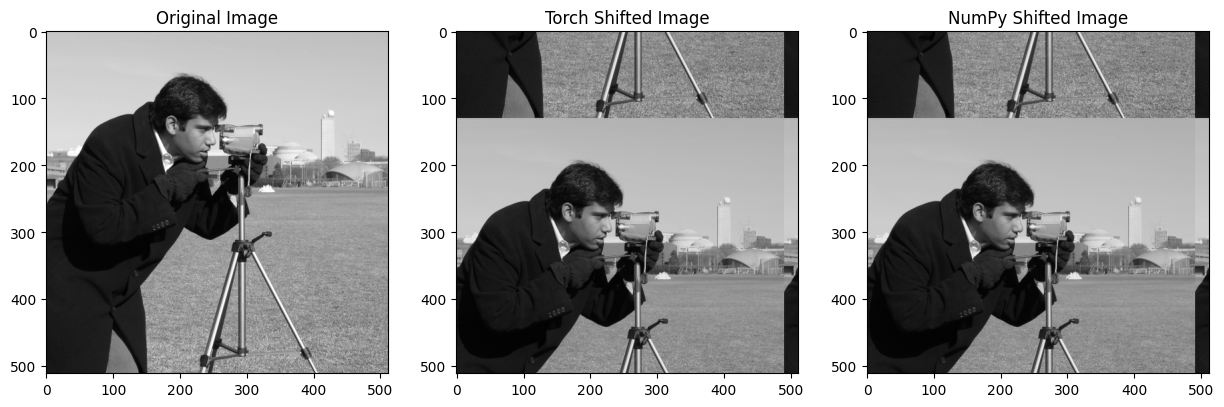

In [4]:
# 2) SHIFT THE IMAGE USING BOTH REGISTRATORS
torch_img_shifted = torch_reg.img_shift(image=img, shift=shift)
numpy_img_shifted = numpy_reg.img_shift(image=img, shift=shift)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.subplot(132)
plt.imshow(torch_img_shifted, cmap='gray')
plt.title("Torch Shifted Image")
plt.subplot(133)
plt.imshow(numpy_img_shifted, cmap='gray')
plt.title("NumPy Shifted Image")
plt.show()

* Register the image using Pytorch

Pytorch | Found shift (y, x): [-130.3000030517578, 20.799999237060547]


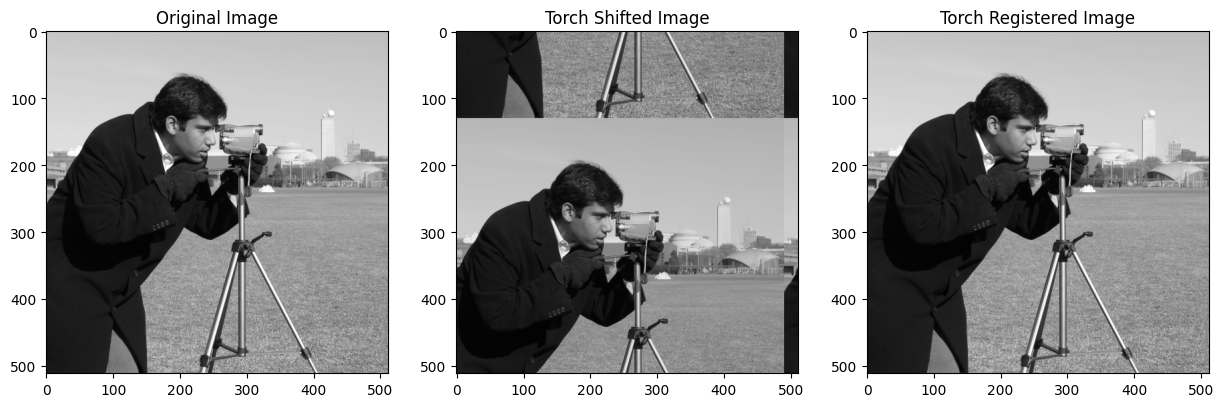

In [5]:
# 3) REGISTER THE SHIFTED IMAGE BACK TO THE ORIGINAL USING PYTORCH REGISTRATOR
torch_reg_shift, torch_img_registered = torch_reg(img, torch_img_shifted)
print("Pytorch | Found shift (y, x):", torch_reg_shift)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.subplot(132)
plt.imshow(torch_img_shifted, cmap='gray')
plt.title("Torch Shifted Image")
plt.subplot(133)
plt.imshow(torch_img_registered, cmap='gray')
plt.title("Torch Registered Image")
plt.show()


* Register the image using Numpy

NumPy   | Found shift (y, x): [-130.3, 20.8]


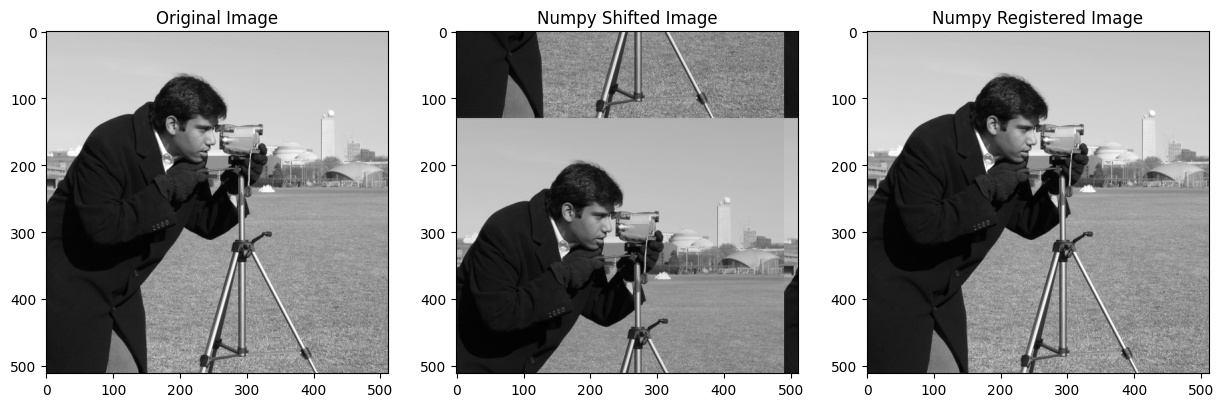

In [6]:
# 4) REGISTER THE SHIFTED IMAGE BACK TO THE ORIGINAL USING NUMPY REGISTRATOR
numpy_reg_shift, numpy_img_registered = numpy_reg(img, numpy_img_shifted)
print("NumPy   | Found shift (y, x):", numpy_reg_shift)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.subplot(132)
plt.imshow(numpy_img_shifted, cmap='gray')
plt.title("Numpy Shifted Image")
plt.subplot(133)
plt.imshow(numpy_img_registered, cmap='gray')
plt.title("Numpy Registered Image")
plt.show()
